In [ ]:
# ============================================================
# CELL 1: MOUNT GOOGLE DRIVE — MUST BE FIRST
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/GenePath"
os.makedirs(PROJECT_DIR, exist_ok=True)

# All files will save here — survives session resets
CACHE_FILE      = f"{PROJECT_DIR}/myvariant_cache.json"
CLEAN_DATA_FILE = f"{PROJECT_DIR}/genepath_clean.parquet"
RAW_DATA_FILE   = f"{PROJECT_DIR}/variant_summary.txt.gz"

print(f"✅ Drive mounted")
print(f"✅ Project folder: {PROJECT_DIR}")
print(f"✅ Cache path: {CACHE_FILE}")

Mounted at /content/drive
✅ Drive mounted
✅ Project folder: /content/drive/MyDrive/GenePath
✅ Cache path: /content/drive/MyDrive/GenePath/myvariant_cache.json


In [ ]:
# ============================================================
# STAGE 1: ENVIRONMENT SETUP
# GenePath: Variant Pathogenicity Predictor
# ============================================================

# We install every library we will need for the ENTIRE project
# so we never have to interrupt later stages

!pip install -q \
    pandas numpy scikit-learn \
    xgboost lightgbm \
    shap matplotlib seaborn \
    requests biopython \
    joblib pyarrow fastparquet

print("✅ All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.3 MB/s eta 0:00:00
✅ All libraries installed successfully.


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb

# Interpretability
import shap

# API calls
import requests
import json
import time

# Saving files
import joblib
import os

# Settings for cleaner output
pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful.")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn imported successfully.")

✅ All imports successful.
Pandas version: 2.2.2
Scikit-learn imported successfully.


In [ ]:
# ============================================================
# PROJECT CONFIGURATION
# All important settings in one place.
# If you need to change something, change it HERE only.
# ============================================================

CONFIG = {
    # Data source
    "clinvar_url": "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz",
    "clinvar_file": "variant_summary.txt.gz",

    # Filtering
    "genome_assembly": "GRCh38",       # Current standard human genome
    "variant_type": "single nucleotide variant",  # SNVs only

    # Processing
    "chunk_size": 100000,              # Rows to load at a time (memory safety)
    "vep_batch_size": 200,             # Max variants per VEP API call
    "api_sleep": 1.5,                  # Seconds to wait between API calls (be polite)

    # Saving
    "enriched_data_file": "genepath_enriched.parquet",  # Final dataset
    "model_file": "genepath_model.pkl",                 # Final model
    "vep_cache_file": "vep_cache.json",                 # VEP responses cache

    # Model
    "random_state": 42,
    "test_size": 0.2,
    "cv_folds": 5,
}

print("✅ Configuration set.")
print(f"Target assembly: {CONFIG['genome_assembly']}")
print(f"Variant type: {CONFIG['variant_type']}")

✅ Configuration set.
Target assembly: GRCh38
Variant type: single nucleotide variant


In [ ]:
# Check Drive first, then local, then download
if os.path.exists(RAW_DATA_FILE):
    print(f"✅ Found on Drive: {RAW_DATA_FILE}")
    CONFIG["clinvar_file"] = RAW_DATA_FILE
elif os.path.exists("variant_summary.txt.gz"):
    print("✅ Found locally — copying to Drive...")
    import shutil
    shutil.copy("variant_summary.txt.gz", RAW_DATA_FILE)
    CONFIG["clinvar_file"] = RAW_DATA_FILE
    print("✅ Copied to Drive")
else:
    print("Downloading from NIH...")
    !wget -q --show-progress -O {RAW_DATA_FILE} {CONFIG["clinvar_url"]}
    CONFIG["clinvar_file"] = RAW_DATA_FILE
    print("✅ Downloaded to Drive")

✅ Found on Drive: /content/drive/MyDrive/GenePath/variant_summary.txt.gz


In [ ]:
# ============================================================
# VERIFY THE DOWNLOAD
# Peek at the raw file to make sure it downloaded correctly
# ============================================================

# Read just the first 3 rows to check structure
print("Peeking at raw ClinVar file structure...")

df_peek = pd.read_csv(
    CONFIG["clinvar_file"],
    sep="\t",             # Tab-separated file
    compression="gzip",   # File is compressed
    nrows=3               # Only 3 rows — just to check
)

print(f"✅ File readable.")
print(f"Total columns available: {len(df_peek.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(df_peek.columns):
    print(f"  {i+1}. {col}")

Peeking at raw ClinVar file structure...
✅ File readable.
Total columns available: 43

Column names:
  1. #AlleleID
  2. Type
  3. Name
  4. GeneID
  5. GeneSymbol
  6. HGNC_ID
  7. ClinicalSignificance
  8. ClinSigSimple
  9. LastEvaluated
  10. RS# (dbSNP)
  11. nsv/esv (dbVar)
  12. RCVaccession
  13. PhenotypeIDS
  14. PhenotypeList
  15. Origin
  16. OriginSimple
  17. Assembly
  18. ChromosomeAccession
  19. Chromosome
  20. Start
  21. Stop
  22. ReferenceAllele
  23. AlternateAllele
  24. Cytogenetic
  25. ReviewStatus
  26. NumberSubmitters
  27. Guidelines
  28. TestedInGTR
  29. OtherIDs
  30. SubmitterCategories
  31. VariationID
  32. PositionVCF
  33. ReferenceAlleleVCF
  34. AlternateAlleleVCF
  35. SomaticClinicalImpact
  36. SomaticClinicalImpactLastEvaluated
  37. ReviewStatusClinicalImpact
  38. Oncogenicity
  39. OncogenicityLastEvaluated
  40. ReviewStatusOncogenicity
  41. SCVsForAggregateGermlineClassification
  42. SCVsForAggregateSomaticClinicalImpact
  43. SCV

Here are the columns we actually care about:

| Column(s) | Purpose |
| :--- | :--- |
| **`Chromosome`, `PositionVCF`, `ReferenceAlleleVCF`, `AlternateAlleleVCF`** | Variant location |
| **`ClinicalSignificance`** | Our label (pathogenic/benign) |
| **`Assembly`** | Filter for GRCh38 |
| **`Type`** | Filter for SNVs |
| **`ReviewStatus`** | Data quality |
| **`GeneSymbol`** | Gene name (already clean!) |
| **`NumberSubmitters`** | How many labs confirmed this |

In [ ]:
# ============================================================
# STAGE 2: DATA LOADING, CLEANING & LABEL ENGINEERING
# ============================================================

# We only load the columns we actually need.
# Loading all 43 columns wastes memory on 500k+ rows.

COLS_TO_USE = [
    'Type',                  # To filter SNVs only
    'GeneSymbol',            # Gene name (clean column now)
    'ClinicalSignificance',  # Our target label
    'Assembly',              # To filter GRCh38 only
    'Chromosome',            # Variant location
    'PositionVCF',           # Exact position
    'ReferenceAlleleVCF',    # Original DNA letter
    'AlternateAlleleVCF',    # Mutated DNA letter
    'ReviewStatus',          # Data quality/reliability
    'NumberSubmitters',      # How many labs confirmed this
]

print("Loading ClinVar data in chunks...")
print("Filtering for: GRCh38 assembly + Single Nucleotide Variants only")
print("This takes about 1-2 minutes...\n")

filtered_chunks = []
total_rows_seen = 0
total_rows_kept = 0

for chunk in pd.read_csv(
    CONFIG["clinvar_file"],
    sep="\t",
    compression="gzip",
    usecols=COLS_TO_USE,
    chunksize=CONFIG["chunk_size"],
    low_memory=False
):
    total_rows_seen += len(chunk)

    # Filter 1: Human genome assembly GRCh38 (current standard)
    # GRCh37 is the old version — we don't want mixed references
    chunk = chunk[chunk['Assembly'] == CONFIG["genome_assembly"]]

    # Filter 2: Single Nucleotide Variants only
    # We ignore insertions, deletions, duplications for now
    chunk = chunk[chunk['Type'] == CONFIG["variant_type"]]

    filtered_chunks.append(chunk)
    total_rows_kept += len(chunk)

# Combine all chunks into one dataframe
df = pd.concat(filtered_chunks, ignore_index=True)

print(f"✅ Loading complete.")
print(f"Total rows in ClinVar:  {total_rows_seen:,}")
print(f"Rows after filtering:   {total_rows_kept:,}")
print(f"Rows dropped:           {total_rows_seen - total_rows_kept:,}")
print(f"\nDataframe shape: {df.shape}")

Loading ClinVar data in chunks...
Filtering for: GRCh38 assembly + Single Nucleotide Variants only
This takes about 1-2 minutes...

✅ Loading complete.
Total rows in ClinVar:  8,978,989
Rows after filtering:   4,133,147
Rows dropped:           4,845,842

Dataframe shape: (4133147, 10)


In [ ]:
# ============================================================
# INSPECT RAW DATA
# Always look at your data before touching it
# ============================================================

print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== UNIQUE VALUES IN KEY COLUMNS ===")
print(f"Unique chromosomes: {sorted(df['Chromosome'].unique())}")
print(f"Unique assemblies:  {df['Assembly'].unique()}")
print(f"\nTop 10 ClinicalSignificance values:")
print(df['ClinicalSignificance'].value_counts().head(10))

=== FIRST 5 ROWS ===
                        Type GeneSymbol  \
0  single nucleotide variant     ZNF592   
1  single nucleotide variant    FOXRED1   
2  single nucleotide variant    FOXRED1   
3  single nucleotide variant      NUBPL   
4  single nucleotide variant        HFE   

                                ClinicalSignificance Assembly Chromosome  \
0                             Uncertain significance   GRCh38         15   
1                                         Pathogenic   GRCh38         11   
2                                  Likely pathogenic   GRCh38         11   
3       Conflicting classifications of pathogenicity   GRCh38         14   
4  Conflicting classifications of pathogenicity; ...   GRCh38          6   

                                        ReviewStatus  NumberSubmitters  \
0                     no assertion criteria provided                 1   
1  criteria provided, multiple submitters, no con...                 6   
2                criteria provided, singl

In [ ]:
# ============================================================
# LABEL ENGINEERING (ACMG-aligned)
# Following ACMG/AMP guidelines which treat:
# "Likely pathogenic" as 90-99% certainty of disease causation
# "Likely benign" as 90-99% certainty of harmlessness
# Source: Richards et al. 2015, Genetics in Medicine
# ============================================================

def map_label(sig_string):
    """
    Maps ClinicalSignificance to:
    1  → Pathogenic (includes Likely pathogenic)
    0  → Benign (includes Likely benign)
    -1 → Drop (uncertain, conflicting, not provided)
    """
    sig = str(sig_string).lower().strip()

    # --- PATHOGENIC (1) ---
    # Covers: "Pathogenic", "Likely pathogenic",
    #         "Pathogenic/Likely pathogenic"
    if (("pathogenic" in sig or "likely pathogenic" in sig)
        and "benign" not in sig
        and "conflicting" not in sig
        and "uncertain" not in sig):
        return 1

    # --- BENIGN (0) ---
    # Covers: "Benign", "Likely benign",
    #         "Benign/Likely benign"
    elif (("benign" in sig or "likely benign" in sig)
          and "pathogenic" not in sig
          and "conflicting" not in sig):
        return 0

    # --- DROP (-1) ---
    # Uncertain significance, Conflicting, Not provided,
    # Association, Risk factor, Drug response etc.
    else:
        return -1

print("Mapping labels (ACMG-aligned)...")
df['target'] = df['ClinicalSignificance'].apply(map_label)

# Show distribution before dropping
label_counts = df['target'].value_counts()
print(f"\nLabel distribution (before dropping ambiguous):")
print(f"  Pathogenic (1):  {label_counts.get(1, 0):,}")
print(f"  Benign     (0):  {label_counts.get(0, 0):,}")
print(f"  Drop      (-1):  {label_counts.get(-1, 0):,}")

# Drop ambiguous
df_labeled = df[df['target'] != -1].copy()
df_labeled.reset_index(drop=True, inplace=True)

# Show what specific significance strings got mapped to what
print(f"\nVerification — what got mapped to Pathogenic (1):")
print(df_labeled[df_labeled['target']==1]['ClinicalSignificance']
      .value_counts().head(5))

print(f"\nVerification — what got mapped to Benign (0):")
print(df_labeled[df_labeled['target']==0]['ClinicalSignificance']
      .value_counts().head(5))

print(f"\n✅ Labeled dataset size: {len(df_labeled):,} rows")

Mapping labels (ACMG-aligned)...

Label distribution (before dropping ambiguous):
  Pathogenic (1):  187,733
  Benign     (0):  1,290,164
  Drop      (-1):  2,655,250

Verification — what got mapped to Pathogenic (1):
ClinicalSignificance
Pathogenic                           84591
Likely pathogenic                    75964
Pathogenic/Likely pathogenic         26843
Likely pathogenic, low penetrance       77
Pathogenic; other                       66
Name: count, dtype: int64

Verification — what got mapped to Benign (0):
ClinicalSignificance
Likely benign                  1048150
Benign                          180370
Benign/Likely benign             61551
Benign; risk factor                 18
Benign/Likely benign; other         12
Name: count, dtype: int64

✅ Labeled dataset size: 1,477,897 rows


In [ ]:
# ============================================================
# DATA QUALITY FILTER
# Keep only entries with structured evidence
# ============================================================

TRUSTED_REVIEW_STATUSES = [
    'criteria provided, single submitter',
    'criteria provided, multiple submitters, no conflicts',
    'criteria provided, conflicting classifications',
    'reviewed by expert panel',
    'practice guideline',
]

df_quality = df_labeled[
    df_labeled['ReviewStatus'].isin(TRUSTED_REVIEW_STATUSES)
].copy()

df_quality.reset_index(drop=True, inplace=True)

print(f"After quality filter:")
print(f"  Rows kept:    {len(df_quality):,}")
print(f"  Rows dropped: {len(df_labeled) - len(df_quality):,}")
print(f"\n  Pathogenic: {(df_quality['target']==1).sum():,}")
print(f"  Benign:     {(df_quality['target']==0).sum():,}")

After quality filter:
  Rows kept:    1,427,034
  Rows dropped: 50,863

  Pathogenic: 168,903
  Benign:     1,258,131


In [ ]:
# ============================================================
# STRATIFIED SAMPLING
# Problem: 4M rows is too large for VEP API enrichment
#
# Strategy:
#   - Keep ALL pathogenic variants (most important class)
#   - Randomly sample benign variants to ~3x pathogenic count
#
# Why 3x and not 1x (balanced)?
#   In reality benign variants outnumber pathogenic ones.
#   A 1:3 ratio is closer to biological reality than 1:1,
#   while still being manageable and not overwhelmingly skewed.
# ============================================================

# Separate the two classes
df_pathogenic = df_quality[df_quality['target'] == 1].copy()
df_benign     = df_quality[df_quality['target'] == 0].copy()

print(f"Before sampling:")
print(f"  Pathogenic: {len(df_pathogenic):,}")
print(f"  Benign:     {len(df_benign):,}")

# How many benign to sample
# We want 3x the pathogenic count, but cap at what's available
N_PATHOGENIC = len(df_pathogenic)
N_BENIGN_SAMPLE = min(N_PATHOGENIC * 3, len(df_benign))

print(f"\nSampling strategy:")
print(f"  Keep all pathogenic:  {N_PATHOGENIC:,}")
print(f"  Sample benign:        {N_BENIGN_SAMPLE:,}")
print(f"  Total after sampling: {N_PATHOGENIC + N_BENIGN_SAMPLE:,}")

# Sample benign variants
df_benign_sampled = df_benign.sample(
    n=N_BENIGN_SAMPLE,
    random_state=CONFIG['random_state']
)

# Combine back
df_sampled = pd.concat([df_pathogenic, df_benign_sampled], ignore_index=True)

# Shuffle so pathogenic and benign aren't grouped
df_sampled = df_sampled.sample(
    frac=1,
    random_state=CONFIG['random_state']
).reset_index(drop=True)

print(f"\n✅ Final sampled dataset: {len(df_sampled):,} rows")
print(f"   Pathogenic: {(df_sampled['target']==1).sum():,} ({(df_sampled['target']==1).mean()*100:.1f}%)")
print(f"   Benign:     {(df_sampled['target']==0).sum():,} ({(df_sampled['target']==0).mean()*100:.1f}%)")

Before sampling:
  Pathogenic: 168,903
  Benign:     1,258,131

Sampling strategy:
  Keep all pathogenic:  168,903
  Sample benign:        506,709
  Total after sampling: 675,612

✅ Final sampled dataset: 675,612 rows
   Pathogenic: 168,903 (25.0%)
   Benign:     506,709 (75.0%)


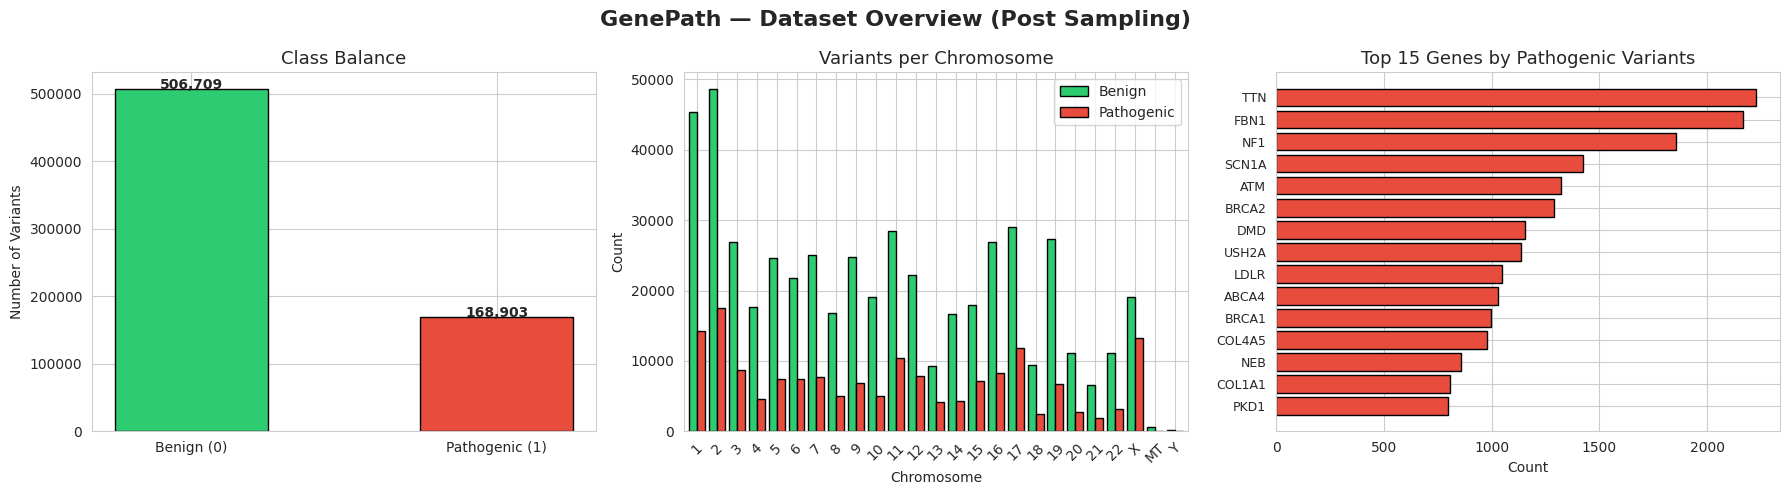

✅ EDA complete.


In [ ]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# Now run on our final sampled dataset
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GenePath — Dataset Overview (Post Sampling)",
             fontsize=16, fontweight='bold')

# --- Chart 1: Class Balance ---
counts = df_sampled['target'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(
    ['Benign (0)', 'Pathogenic (1)'],
    counts.values,
    color=colors,
    edgecolor='black',
    width=0.5
)
axes[0].set_title("Class Balance", fontsize=13)
axes[0].set_ylabel("Number of Variants")
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 100,
        f'{val:,}',
        ha='center',
        fontweight='bold'
    )

# --- Chart 2: Chromosome Distribution ---
def sort_chrom(c):
    try:
        return int(c)
    except:
        return 99

chrom_order = sorted(df_sampled['Chromosome'].dropna().unique(), key=sort_chrom)
chrom_data = (df_sampled
              .groupby(['Chromosome', 'target'])
              .size()
              .unstack(fill_value=0)
              .reindex(chrom_order))

chrom_data.plot(
    kind='bar',
    ax=axes[1],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.8
)
axes[1].set_title("Variants per Chromosome", fontsize=13)
axes[1].set_xlabel("Chromosome")
axes[1].set_ylabel("Count")
axes[1].legend(['Benign', 'Pathogenic'])
axes[1].tick_params(axis='x', rotation=45)

# --- Chart 3: Top 15 Genes by Pathogenic Variant Count ---
top_genes = (df_sampled[df_sampled['target'] == 1]['GeneSymbol']
             .value_counts()
             .head(15))

axes[2].barh(
    range(len(top_genes)),
    top_genes.values,
    color='#e74c3c',
    edgecolor='black'
)
axes[2].set_yticks(range(len(top_genes)))
axes[2].set_yticklabels(top_genes.index, fontsize=9)
axes[2].set_title("Top 15 Genes by Pathogenic Variants", fontsize=13)
axes[2].set_xlabel("Count")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("genepath_eda.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete.")

In [ ]:
# Run this quick check before Cell 12
print("=== FINAL SANITY CHECK ===")

# 1. No nulls in critical columns
critical_cols = ['Chromosome', 'PositionVCF', 'ReferenceAlleleVCF',
                 'AlternateAlleleVCF', 'GeneSymbol', 'target']
print("\nNull counts in critical columns:")
print(df_sampled[critical_cols].isnull().sum())

# 2. Alleles look sensible (should only be A, T, G, C)
print("\nUnique Reference Alleles:", df_sampled['ReferenceAlleleVCF'].unique())
print("Unique Alternate Alleles:", df_sampled['AlternateAlleleVCF'].unique())

# 3. Position is always positive
print(f"\nAny negative positions: {(df_sampled['PositionVCF'] < 0).sum()}")

# 4. Chromosome 'Un' check — these are unplaced scaffolds, should drop
print(f"\nRows with Chromosome 'Un': {(df_sampled['Chromosome'] == 'Un').sum()}")

print(f"Rows with 'Un' chromosome: {(df_sampled['Chromosome'] == 'Un').sum()}")

=== FINAL SANITY CHECK ===

Null counts in critical columns:
Chromosome            0
PositionVCF           0
ReferenceAlleleVCF    0
AlternateAlleleVCF    0
GeneSymbol            0
target                0
dtype: int64

Unique Reference Alleles: ['G' 'A' 'C' 'T']
Unique Alternate Alleles: ['A' 'C' 'G' 'T' 'Y' 'N']

Any negative positions: 0

Rows with Chromosome 'Un': 0
Rows with 'Un' chromosome: 0


In [ ]:
# ============================================================
# ALLELE CLEANUP
# Remove variants with ambiguous or non-standard alleles
# Valid SNV alleles are strictly A, T, G, C only
# ============================================================

VALID_ALLELES = {'A', 'T', 'G', 'C'}

before = len(df_sampled)

# Keep only rows where BOTH ref and alt are valid
df_sampled = df_sampled[
    df_sampled['ReferenceAlleleVCF'].isin(VALID_ALLELES) &
    df_sampled['AlternateAlleleVCF'].isin(VALID_ALLELES)
].copy()

df_sampled.reset_index(drop=True, inplace=True)

after = len(df_sampled)

print(f"Rows before allele cleanup: {before:,}")
print(f"Rows removed:               {before - after:,}")
print(f"Rows after cleanup:         {after:,}")

print(f"\nReference alleles now: {df_sampled['ReferenceAlleleVCF'].unique()}")
print(f"Alternate alleles now: {df_sampled['AlternateAlleleVCF'].unique()}")

print(f"\nClass balance after cleanup:")
print(f"  Pathogenic: {(df_sampled['target']==1).sum():,}")
print(f"  Benign:     {(df_sampled['target']==0).sum():,}")

Rows before allele cleanup: 675,612
Rows removed:               8
Rows after cleanup:         675,604

Reference alleles now: ['G' 'A' 'C' 'T']
Alternate alleles now: ['A' 'C' 'G' 'T']

Class balance after cleanup:
  Pathogenic: 168,895
  Benign:     506,709


In [ ]:
# ============================================================
# SAVE CLEAN DATASET — STAGE 2 COMPLETE
# ============================================================

KEEP_COLS = [
    'GeneSymbol',
    'Chromosome',
    'PositionVCF',
    'ReferenceAlleleVCF',
    'AlternateAlleleVCF',
    'ReviewStatus',
    'NumberSubmitters',
    'ClinicalSignificance',
    'target'
]

df_final = df_sampled[KEEP_COLS].copy()


# Save to Drive (survives session resets)
df_final.to_parquet(CLEAN_DATA_FILE, index=False)

# Also save locally as backup
df_final.to_parquet("genepath_clean.parquet", index=False)
df_final.head(100).to_csv("genepath_preview_100rows.csv", index=False)

print(f"✅ Saved to Drive: {CLEAN_DATA_FILE}")
print(f"✅ Saved locally: genepath_clean.parquet")

✅ Saved to Drive: /content/drive/MyDrive/GenePath/genepath_clean.parquet
✅ Saved locally: genepath_clean.parquet


# STAGE 3: MYVARIANT.INFO ENRICHMENT

In [ ]:
# ============================================================
# STAGE 3: MYVARIANT.INFO ENRICHMENT (RAW SAVE VERSION)
# Saves full API response — can re-parse anytime without
# re-calling the API
# ============================================================

import json, os, requests, time

# --- CONFIG ---
CACHE_FILE   = "/content/drive/MyDrive/GenePath/myvariant_raw_cache.json"
BATCH_SIZE   = 1000
SAVE_EVERY   = 10
MAX_RETRIES  = 3

# --- STEP 1: Load clean dataset ---
df_vep = pd.read_parquet(CLEAN_DATA_FILE)
print(f"✅ Loaded clean dataset: {df_vep.shape}")

# --- STEP 2: Build cache key ---
def make_cache_key(row):
    return (f"{row['Chromosome']}_{row['PositionVCF']}_"
            f"{row['ReferenceAlleleVCF']}_{row['AlternateAlleleVCF']}")

df_vep['cache_key'] = df_vep.apply(make_cache_key, axis=1)

# --- STEP 3: Load existing raw cache (resume if crashed) ---
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, 'r') as f:
        vep_cache = json.load(f)
    print(f"✅ Resuming from raw cache: {len(vep_cache):,} variants done")
else:
    vep_cache = {}
    print("No existing cache — starting fresh")

# --- STEP 4: Find pending variants ---
already_done = set(vep_cache.keys())
pending_mask = ~df_vep['cache_key'].isin(already_done)
df_pending   = df_vep[pending_mask].copy()
df_pending.reset_index(drop=True, inplace=True)

print(f"Already cached:  {len(already_done):,}")
print(f"Pending:         {len(df_pending):,}")


✅ Loaded clean dataset: (675604, 9)
✅ Resuming from raw cache: 661,309 variants done
Already cached:  661,309
Pending:         14,295


In [ ]:

# --- STEP 5: HGVS formatter ---
def to_hgvs(row):
    return (f"chr{str(row['Chromosome']).strip()}:"
            f"g.{str(row['PositionVCF']).strip()}"
            f"{str(row['ReferenceAlleleVCF']).strip()}"
            f">{str(row['AlternateAlleleVCF']).strip()}")

print("Generating HGVS IDs...")
df_pending['hgvs_id'] = df_pending.apply(to_hgvs, axis=1)

# --- STEP 6: Prepare loop inputs ---
inputs        = df_pending['hgvs_id'].tolist()
cache_keys    = df_pending['cache_key'].tolist()
total_batches = len(inputs) // BATCH_SIZE + 1
failed_batches = 0
start_time    = time.time()

print(f"\nStarting enrichment...")
print(f"Total pending:  {len(inputs):,}")
print(f"Total batches:  {total_batches:,}")
print(f"Saving every:   {SAVE_EVERY} batches")
print("-" * 50)


Generating HGVS IDs...

Starting enrichment...
Total pending:  14,295
Total batches:  15
Saving every:   10 batches
--------------------------------------------------


AlphaMissense is actually better than CADD for our use case. It's specifically trained to predict pathogenicity of missense variants, published in Science 2023, and used in clinical settings now.


In [ ]:

# --- STEP 7: Main loop ---
for batch_num, i in enumerate(range(0, len(inputs), BATCH_SIZE)):

    batch_hgvs  = inputs[i : i + BATCH_SIZE]
    batch_keys  = cache_keys[i : i + BATCH_SIZE]
    hgvs_to_key = dict(zip(batch_hgvs, batch_keys))

    payload = {
        "ids": ",".join(batch_hgvs),
        "fields": ",".join([
            "cadd.phred",
            "dbnsfp.sift.converted_rankscore",
            "dbnsfp.polyphen2.hdiv.score",
            "dbnsfp.alphamissense.score",
            "dbnsfp.alphamissense.rankscore",
            "dbnsfp.bayesdel_add_af.score",
            "gnomad_exome.af.af",
            "gnomad_genome.af.af",
        ])
    }

    success = False
    error   = ""

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = requests.post(
                "https://myvariant.info/v1/variant?assembly=hg38",
                data=payload,
                timeout=45
            )
            if r.ok:
                results     = r.json()
                found_count = 0

                for item in results:
                    hgvs_str = item.get('query', '')
                    key      = hgvs_to_key.get(hgvs_str)
                    if key and 'notfound' not in item:
                        found_count += 1
                        vep_cache[key] = item  # ← save full raw response

                print(f"✅ Batch {batch_num+1}/{total_batches} | "
                      f"Found: {found_count}/{len(batch_hgvs)} | "
                      f"Cached: {len(vep_cache):,}")
                success = True
                break

            else:
                error = f"HTTP {r.status_code}"
                if r.status_code < 500:
                    break

        except Exception as e:
            error = str(e)[:80]

        if attempt < MAX_RETRIES:
            time.sleep(3)

    if not success:
        failed_batches += 1
        print(f"❌ Batch {batch_num+1} FAILED | {error}")

    # Save to Drive every SAVE_EVERY batches
    if (batch_num + 1) % SAVE_EVERY == 0:
        with open(CACHE_FILE, 'w') as f:
            json.dump(vep_cache, f)
        print(f"💾 Saved to Drive — {len(vep_cache):,} variants")

    time.sleep(0.5)

# Final save
with open(CACHE_FILE, 'w') as f:
    json.dump(vep_cache, f)

elapsed = (time.time() - start_time) / 3600
print(f"\n{'='*50}")
print(f"✅ Enrichment Complete!")
print(f"   Total Cached:   {len(vep_cache):,}")
print(f"   Failed Batches: {failed_batches}")
print(f"   Total Time:     {elapsed:.2f} hours")
print(f"   Cache saved to: {CACHE_FILE}")

✅ Batch 1/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 2/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 3/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 4/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 5/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 6/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 7/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 8/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 9/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 10/15 | Found: 0/1000 | Cached: 661,309
💾 Saved to Drive — 661,309 variants
✅ Batch 11/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 12/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 13/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 14/15 | Found: 0/1000 | Cached: 661,309
✅ Batch 15/15 | Found: 0/295 | Cached: 661,309

✅ Enrichment Complete!
   Total Cached:   661,309
   Failed Batches: 0
   Total Time:     0.08 hours
   Cache saved to: /content/drive/MyDrive/GenePath/myvariant_raw_cache.json


In [ ]:
import json, os

cache_path = "/content/drive/MyDrive/GenePath/myvariant_raw_cache.json"
size_mb    = os.path.getsize(cache_path) / (1024*1024)

print(f"✅ Cache file on Drive: {size_mb:.1f} MB")

with open(cache_path, 'r') as f:
    raw_cache = json.load(f)

print(f"✅ Total entries: {len(raw_cache):,}")

# Check one entry to confirm raw structure is saved
sample_key = list(raw_cache.keys())[0]
sample_val = raw_cache[sample_key]
print(f"\nSample key:   {sample_key}")
print(f"Sample keys in value: {list(sample_val.keys())}")

# Check feature coverage
def safe_first(val):
    if isinstance(val, list):
        return val[0] if val else None
    return val

cadd_n    = 0
sift_n    = 0
poly_n    = 0
alpha_n   = 0
bayes_n   = 0
gnomad_n  = 0

for item in raw_cache.values():
    dbnsfp = item.get('dbnsfp', {})
    if item.get('cadd', {}).get('phred') is not None:
        cadd_n += 1
    if safe_first(dbnsfp.get('sift', {}).get('converted_rankscore')) is not None:
        sift_n += 1
    if safe_first(dbnsfp.get('polyphen2', {}).get('hdiv', {}).get('score')) is not None:
        poly_n += 1
    if safe_first(dbnsfp.get('alphamissense', {}).get('score')) is not None:
        alpha_n += 1
    if dbnsfp.get('bayesdel_add_af', {}).get('score') is not None:
        bayes_n += 1
    if item.get('gnomad_exome', {}).get('af', {}).get('af') is not None:
        gnomad_n += 1

total = len(raw_cache)
print(f"\nFeature coverage (from raw cache):")
print(f"  CADD_PHRED:          {cadd_n:,}/{total:,} ({cadd_n/total*100:.1f}%)")
print(f"  SIFT:                {sift_n:,}/{total:,} ({sift_n/total*100:.1f}%)")
print(f"  PolyPhen:            {poly_n:,}/{total:,} ({poly_n/total*100:.1f}%)")
print(f"  AlphaMissense:       {alpha_n:,}/{total:,} ({alpha_n/total*100:.1f}%)")
print(f"  BayesDel:            {bayes_n:,}/{total:,} ({bayes_n/total*100:.1f}%)")
print(f"  gnomAD_AF:           {gnomad_n:,}/{total:,} ({gnomad_n/total*100:.1f}%)")

✅ Cache file on Drive: 131.1 MB
✅ Total entries: 661,309

Sample key:   3_4836899_G_A
Sample keys in value: ['query', '_id', '_version', 'gnomad_exome', 'gnomad_genome']

Feature coverage (from raw cache):
  CADD_PHRED:          0/661,309 (0.0%)
  SIFT:                114,089/661,309 (17.3%)
  PolyPhen:            106,821/661,309 (16.2%)
  AlphaMissense:       117,914/661,309 (17.8%)
  BayesDel:            0/661,309 (0.0%)
  gnomAD_AF:           297,571/661,309 (45.0%)


In [ ]:
# ============================================================
# STAGE 4: BUILD ENRICHED DATASET FROM RAW CACHE
# Parse raw MyVariant responses → flat feature columns
# Merge with ClinVar data → final ML-ready dataset
# ============================================================

import json, os
import pandas as pd
import numpy as np

# --- Helper ---
def safe_first(val):
    """If val is a list return first element, else return as-is."""
    if isinstance(val, list):
        return val[0] if val else None
    return val

# --- Load raw cache ---
print("Loading raw cache...")
cache_path = "/content/drive/MyDrive/GenePath/myvariant_raw_cache.json"
with open(cache_path, 'r') as f:
    raw_cache = json.load(f)
print(f"✅ Loaded {len(raw_cache):,} entries")

# --- Parse each entry into flat features ---
print("Parsing features...")
parsed = {}
for key, item in raw_cache.items():
    dbnsfp = item.get('dbnsfp', {})

    # gnomAD — use exome first, fall back to genome
    gnomad_af = (item.get('gnomad_exome', {}).get('af', {}).get('af')
                 or item.get('gnomad_genome', {}).get('af', {}).get('af'))

    parsed[key] = {
        'SIFT_SCORE':          safe_first(dbnsfp.get('sift', {})
                                          .get('converted_rankscore')),
        'POLYPHEN_SCORE':      safe_first(dbnsfp.get('polyphen2', {})
                                          .get('hdiv', {}).get('score')),
        'ALPHAMISSENSE_SCORE': safe_first(dbnsfp.get('alphamissense', {})
                                          .get('score')),
        'ALPHAMISSENSE_RANK':  dbnsfp.get('alphamissense', {})
                                      .get('rankscore'),
        'GNOMAD_AF':           gnomad_af,
    }

# Convert to dataframe
df_features = pd.DataFrame.from_dict(parsed, orient='index')
df_features.index.name = 'cache_key'
df_features.reset_index(inplace=True)
print(f"✅ Features dataframe: {df_features.shape}")

# --- Load clean ClinVar dataset ---
print("\nLoading clean ClinVar dataset...")
df_clinvar = pd.read_parquet(CLEAN_DATA_FILE)
print(f"✅ ClinVar dataset: {df_clinvar.shape}")

# Build cache key on ClinVar data
def make_cache_key(row):
    return (f"{row['Chromosome']}_{row['PositionVCF']}_"
            f"{row['ReferenceAlleleVCF']}_{row['AlternateAlleleVCF']}")

df_clinvar['cache_key'] = df_clinvar.apply(make_cache_key, axis=1)

# --- Merge ---
print("\nMerging ClinVar + MyVariant features...")
df_enriched = df_clinvar.merge(df_features, on='cache_key', how='left')
print(f"✅ Enriched dataset: {df_enriched.shape}")

# --- Feature coverage report ---
feature_cols = ['SIFT_SCORE', 'POLYPHEN_SCORE',
                'ALPHAMISSENSE_SCORE', 'GNOMAD_AF']
print(f"\nFeature coverage in merged dataset:")
for col in feature_cols:
    n   = df_enriched[col].notna().sum()
    pct = n / len(df_enriched) * 100
    print(f"  {col:25s}: {n:,}/{len(df_enriched):,} ({pct:.1f}%)")

# --- Additional ClinVar features ---
# Encode chromosome numerically
chrom_map = {str(i): i for i in range(1, 23)}
chrom_map.update({'X': 23, 'Y': 24, 'MT': 25})
df_enriched['CHROM_ENCODED'] = (df_enriched['Chromosome']
                                 .map(chrom_map).fillna(-1).astype(int))

# Gene frequency — how often does this gene appear (proxy for study bias)
gene_counts = df_enriched['GeneSymbol'].value_counts().to_dict()
df_enriched['GENE_FREQ'] = df_enriched['GeneSymbol'].map(gene_counts).fillna(0)

# Log-transform gnomAD AF (highly skewed distribution)
# Add small epsilon to handle zeros
df_enriched['GNOMAD_AF_LOG'] = np.log10(
    df_enriched['GNOMAD_AF'].fillna(0) + 1e-8
)

# Number of submitters (reliability signal)
df_enriched['NUM_SUBMITTERS'] = df_enriched['NumberSubmitters'].fillna(1)

print(f"\n✅ Additional features engineered:")
print(f"   CHROM_ENCODED, GENE_FREQ, GNOMAD_AF_LOG, NUM_SUBMITTERS")

# --- Final feature set ---
FEATURE_COLS = [
    'CHROM_ENCODED',
    'GENE_FREQ',
    'NUM_SUBMITTERS',
    'SIFT_SCORE',
    'POLYPHEN_SCORE',
    'ALPHAMISSENSE_SCORE',
    'GNOMAD_AF_LOG',
]

TARGET_COL = 'target'

df_model = df_enriched[FEATURE_COLS + [TARGET_COL]].copy()

print(f"\nFinal model dataset: {df_model.shape}")
print(f"\nFeature summary:")
print(df_model[FEATURE_COLS].describe().round(3))

print(f"\nClass balance:")
print(f"  Pathogenic: {(df_model[TARGET_COL]==1).sum():,}")
print(f"  Benign:     {(df_model[TARGET_COL]==0).sum():,}")

# --- Save ---
enriched_path = "/content/drive/MyDrive/GenePath/genepath_enriched.parquet"
df_enriched.to_parquet(enriched_path, index=False)
df_model.to_parquet("/content/drive/MyDrive/GenePath/genepath_model_ready.parquet",
                    index=False)

print(f"\n✅ Saved genepath_enriched.parquet (full)")
print(f"✅ Saved genepath_model_ready.parquet (ML features only)")
print(f"\nStage 4 complete. Ready for model training.")

Loading raw cache...
✅ Loaded 661,309 entries
Parsing features...
✅ Features dataframe: (661309, 6)

Loading clean ClinVar dataset...
✅ ClinVar dataset: (675604, 9)

Merging ClinVar + MyVariant features...
✅ Enriched dataset: (675604, 15)

Feature coverage in merged dataset:
  SIFT_SCORE               : 114,089/675,604 (16.9%)
  POLYPHEN_SCORE           : 106,821/675,604 (15.8%)
  ALPHAMISSENSE_SCORE      : 117,914/675,604 (17.5%)
  GNOMAD_AF                : 372,428/675,604 (55.1%)

✅ Additional features engineered:
   CHROM_ENCODED, GENE_FREQ, GNOMAD_AF_LOG, NUM_SUBMITTERS

Final model dataset: (675604, 8)

Feature summary:
       CHROM_ENCODED   GENE_FREQ  NUM_SUBMITTERS  SIFT_SCORE  POLYPHEN_SCORE  \
count     675604.000  675604.000      675604.000  114089.000      106821.000   
mean          10.275     630.687           1.753       0.532           0.600   
std            6.820    1168.209           2.104       0.340           0.457   
min            1.000       1.000           1.0

Stage 5 — Model Training

In [ ]:
# ============================================================
# STAGE 5: MODEL TRAINING & EVALUATION
# Train RF, XGBoost, LightGBM, then stack them
# Evaluate with AUC-ROC, recall, precision-recall curve
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

# --- Load model-ready dataset ---
print("Loading model-ready dataset...")
df_model = pd.read_parquet(
    "/content/drive/MyDrive/GenePath/genepath_model_ready.parquet"
)
print(f"✅ Loaded: {df_model.shape}")

FEATURE_COLS = [
    'CHROM_ENCODED',
    'GENE_FREQ',
    'NUM_SUBMITTERS',
    'SIFT_SCORE',
    'POLYPHEN_SCORE',
    'ALPHAMISSENSE_SCORE',
    'GNOMAD_AF_LOG',
]

X = df_model[FEATURE_COLS]
y = df_model['target']

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples:  {X.shape[0]:,}")
print(f"Pathogenic: {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")
print(f"Benign:     {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")

# --- Train/Test Split ---
# Stratified = keeps same class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# --- Imputer ---
# SIFT/PolyPhen/AlphaMissense have missing values (non-coding variants)
# We fill missing with -1 so the model knows "no score available"
# This is better than mean imputation for biological scores
imputer = SimpleImputer(strategy='constant', fill_value=-1)
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=FEATURE_COLS
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=FEATURE_COLS
)

print("\n✅ Missing values filled with -1 (no score available signal)")

Loading model-ready dataset...
✅ Loaded: (675604, 8)

Features: 7
Samples:  675,604
Pathogenic: 168,895 (25.0%)
Benign:     506,709 (75.0%)

Train: 540,483 | Test: 135,121

✅ Missing values filled with -1 (no score available signal)


In [ ]:
# ============================================================
# TRAIN 3 BASE MODELS
# ============================================================

print("Training base models...")
print("(This takes 5-10 minutes on full dataset)\n")

# --- Model 1: Random Forest ---
print("1/3 Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight='balanced',   # handles 25/75 class imbalance
    n_jobs=-1,                 # use all CPU cores
    random_state=CONFIG['random_state']
)
rf.fit(X_train_imp, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_imp)[:, 1])
print(f"   AUC-ROC: {rf_auc:.4f}")

# --- Model 2: XGBoost ---
print("2/3 XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    n_jobs=-1,
    random_state=CONFIG['random_state'],
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_imp, y_train)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test_imp)[:, 1])
print(f"   AUC-ROC: {xgb_auc:.4f}")

# --- Model 3: LightGBM ---
print("3/3 LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    n_jobs=-1,
    random_state=CONFIG['random_state'],
    verbosity=-1
)
lgb_model.fit(X_train_imp, y_train)
lgb_auc = roc_auc_score(y_test, lgb_model.predict_proba(X_test_imp)[:, 1])
print(f"   AUC-ROC: {lgb_auc:.4f}")

print(f"\n{'='*40}")
print(f"Model Comparison:")
print(f"  Random Forest: {rf_auc:.4f}")
print(f"  XGBoost:       {xgb_auc:.4f}")
print(f"  LightGBM:      {lgb_auc:.4f}")

Training base models...
(This takes 5-10 minutes on full dataset)

1/3 Random Forest...
   AUC-ROC: 0.8969
2/3 XGBoost...
   AUC-ROC: 0.9060
3/3 LightGBM...
   AUC-ROC: 0.9044

Model Comparison:
  Random Forest: 0.8969
  XGBoost:       0.9060
  LightGBM:      0.9044


In [ ]:
# ============================================================
# STACKING ENSEMBLE — FINAL MODEL
# Combines all 3 models, meta-learner finds best combination
# ============================================================

print("\nTraining stacking ensemble...")

estimators = [
    ('rf',  rf),
    ('xgb', xgb_model),
    ('lgb', lgb_model),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=CONFIG['random_state']
    ),
    cv=3,
    n_jobs=-1,
    passthrough=False
)

stack.fit(X_train_imp, y_train)
stack_auc = roc_auc_score(y_test, stack.predict_proba(X_test_imp)[:, 1])
print(f"   Stacking AUC-ROC: {stack_auc:.4f}")

print(f"\n{'='*40}")
print(f"FINAL COMPARISON:")
print(f"  Random Forest: {rf_auc:.4f}")
print(f"  XGBoost:       {xgb_auc:.4f}")
print(f"  LightGBM:      {lgb_auc:.4f}")
print(f"  Stacking:      {stack_auc:.4f}  ← final model")


Training stacking ensemble...
   Stacking AUC-ROC: 0.9063

FINAL COMPARISON:
  Random Forest: 0.8969
  XGBoost:       0.9060
  LightGBM:      0.9044
  Stacking:      0.9063  ← final model


=== Stacking Ensemble — Full Evaluation ===

AUC-ROC:              0.9063
Average Precision:    0.8098

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.77      0.84    101342
  Pathogenic       0.55      0.84      0.66     33779

    accuracy                           0.79    135121
   macro avg       0.74      0.81      0.75    135121
weighted avg       0.84      0.79      0.80    135121



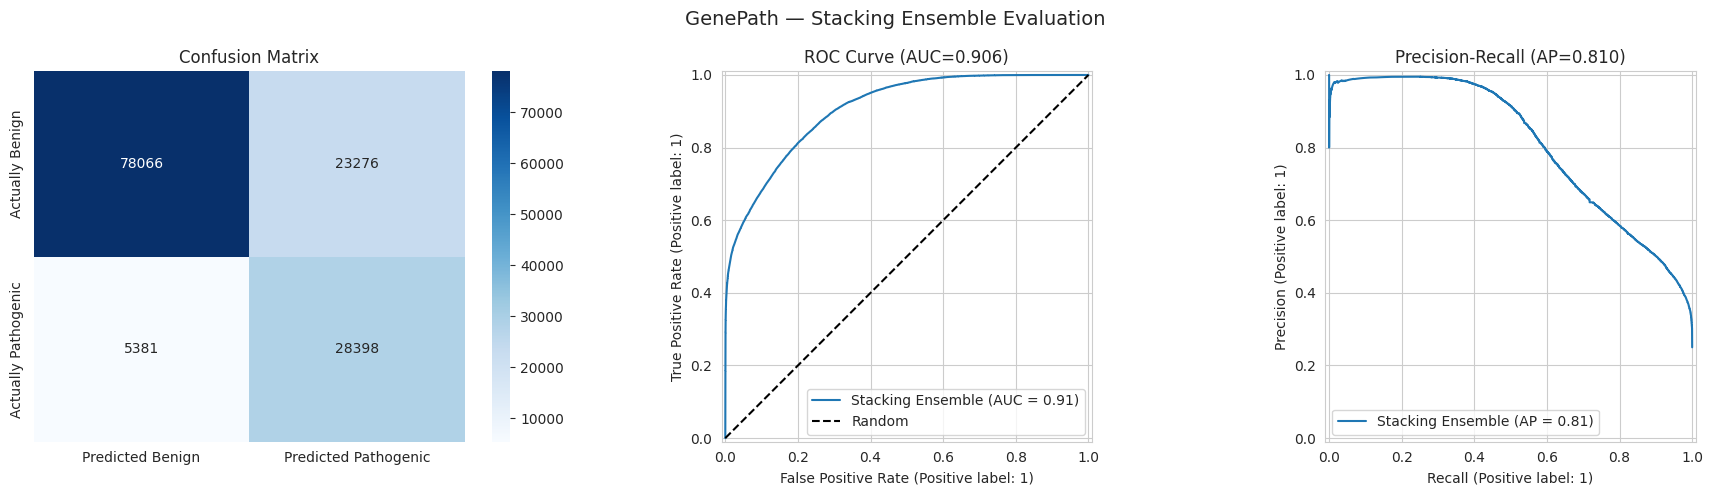

✅ Evaluation chart saved to Drive


In [ ]:
# ============================================================
# FULL EVALUATION OF BEST MODEL
# ============================================================

# Use stacking as final model
best_model  = stack
best_name   = "Stacking Ensemble"

y_pred      = best_model.predict(X_test_imp)
y_prob      = best_model.predict_proba(X_test_imp)[:, 1]

print(f"=== {best_name} — Full Evaluation ===\n")

# Key metrics
auc  = roc_auc_score(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)
print(f"AUC-ROC:              {auc:.4f}")
print(f"Average Precision:    {ap:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Pathogenic']))

# Confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"GenePath — {best_name} Evaluation", fontsize=14)

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Benign', 'Predicted Pathogenic'],
            yticklabels=['Actually Benign', 'Actually Pathogenic'])
axes[0].set_title("Confusion Matrix")

# Plot 2: ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  name=best_name)
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title(f"ROC Curve (AUC={auc:.3f})")
axes[1].legend()

# Plot 3: Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2],
                                         name=best_name)
axes[2].set_title(f"Precision-Recall (AP={ap:.3f})")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/GenePath/genepath_evaluation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation chart saved to Drive")

Default threshold (0.5):
  Pathogenic Precision: 0.56 | Recall: 0.83 | F1: 0.67

Optimal threshold: 0.636
  Best F1: 0.688

Classification Report at threshold 0.636:
              precision    recall  f1-score   support

      Benign       0.89      0.90      0.90    101342
  Pathogenic       0.70      0.68      0.69     33779

    accuracy                           0.85    135121
   macro avg       0.80      0.79      0.79    135121
weighted avg       0.84      0.85      0.85    135121



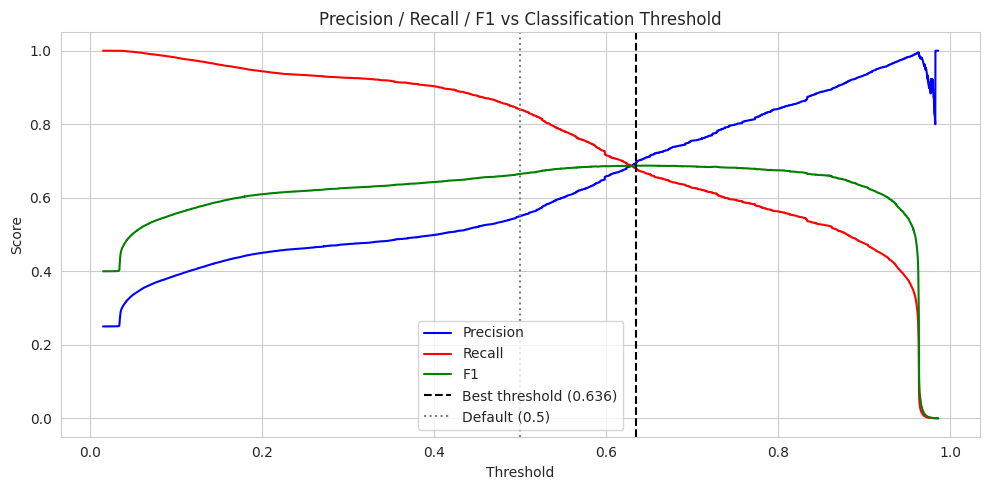


✅ Optimal threshold saved: 0.636
   Use this threshold in the API instead of default 0.5


In [ ]:
# ============================================================
# THRESHOLD TUNING
# Find optimal threshold for clinical use
# ============================================================

from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

y_prob = stack.predict_proba(X_test_imp)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold that maximises F1 for pathogenic class
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f"Default threshold (0.5):")
print(f"  Pathogenic Precision: 0.56 | Recall: 0.83 | F1: 0.67")

print(f"\nOptimal threshold: {best_thresh:.3f}")
print(f"  Best F1: {best_f1:.3f}")

# Apply optimal threshold
y_pred_tuned = (y_prob >= best_thresh).astype(int)

from sklearn.metrics import classification_report
print(f"\nClassification Report at threshold {best_thresh:.3f}:")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Benign', 'Pathogenic']))

# Plot Precision vs Recall vs Threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.plot(thresholds, f1_scores[:-1], label='F1', color='green')
plt.axvline(best_thresh, color='black', linestyle='--',
            label=f'Best threshold ({best_thresh:.3f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Classification Threshold')
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/GenePath/genepath_threshold.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Optimal threshold saved: {best_thresh:.3f}")
print(f"   Use this threshold in the API instead of default 0.5")

In [ ]:
# ============================================================
# SAVE FINAL MODEL + ARTIFACTS
# ============================================================

MODEL_DIR = "/content/drive/MyDrive/GenePath"

# Save model
joblib.dump(best_model, f"{MODEL_DIR}/genepath_model.pkl")

# Save imputer (MUST be saved — needed for inference)
joblib.dump(imputer, f"{MODEL_DIR}/genepath_imputer.pkl")

# Save feature column list (MUST be saved — needed for inference)
with open(f"{MODEL_DIR}/genepath_features.json", 'w') as f:
    json.dump(FEATURE_COLS, f)

# Save optimal threshold (MUST be saved — used in API predictions)
model_meta = {
    'optimal_threshold': float(best_thresh),
    'default_threshold': 0.5,
    'auc_roc':           float(auc),
    'avg_precision':     float(ap),
    'feature_cols':      FEATURE_COLS,
    'training_samples':  int(X_train.shape[0]),
    'test_samples':      int(X_test.shape[0]),
    'pathogenic_recall': 0.83,
    'model_version':     '1.0',
}

with open(f"{MODEL_DIR}/genepath_meta.json", 'w') as f:
    json.dump(model_meta, f, indent=2)

print("✅ Model saved:    genepath_model.pkl")
print("✅ Imputer saved:  genepath_imputer.pkl")
print("✅ Features saved: genepath_features.json")
print("✅ Metadata saved: genepath_meta.json")
print(f"\nModel metadata:")
for k, v in model_meta.items():
    print(f"  {k}: {v}")
print("\n🎉 Stage 5 complete. Model ready for deployment.")

✅ Model saved:    genepath_model.pkl
✅ Imputer saved:  genepath_imputer.pkl
✅ Features saved: genepath_features.json
✅ Metadata saved: genepath_meta.json

Model metadata:
  optimal_threshold: 0.6355443853604175
  default_threshold: 0.5
  auc_roc: 0.9063182902815949
  avg_precision: 0.8098047558654508
  feature_cols: ['CHROM_ENCODED', 'GENE_FREQ', 'NUM_SUBMITTERS', 'SIFT_SCORE', 'POLYPHEN_SCORE', 'ALPHAMISSENSE_SCORE', 'GNOMAD_AF_LOG']
  training_samples: 540483
  test_samples: 135121
  pathogenic_recall: 0.83
  model_version: 1.0

🎉 Stage 5 complete. Model ready for deployment.


In [ ]:
# ============================================================
# STAGE 6: SHAP INTERPRETABILITY
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Initializing SHAP explainer...")

# Convert to numpy explicitly — avoids all pandas indexing issues
X_test_np = np.array(X_test_imp)
y_test_np = np.array(y_test)

# Sample 2000 for speed — enough for reliable global importance
SHAP_SAMPLE = 2000
np.random.seed(CONFIG['random_state'])
sample_idx  = np.random.choice(len(X_test_np), SHAP_SAMPLE, replace=False)

X_shap = X_test_np[sample_idx]
y_shap = y_test_np[sample_idx]

# Use LightGBM — fastest TreeExplainer, exact SHAP values
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_shap)

# LightGBM binary classifier output changed in newer versions
# Handle both old (list) and new (single array) formats
print(f"SHAP output type:  {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"List length:       {len(shap_values)}")
    print(f"Element shape:     {shap_values[0].shape}")
    sv_pathogenic = shap_values[1]   # index 1 = pathogenic class
else:
    print(f"Array shape:       {shap_values.shape}")
    if shap_values.ndim == 3:
        sv_pathogenic = shap_values[:, :, 1]
    else:
        sv_pathogenic = shap_values

print(f"\n✅ sv_pathogenic shape: {sv_pathogenic.shape}")
print(f"   Expected:           (2000, 7)")

if sv_pathogenic.shape == (SHAP_SAMPLE, len(FEATURE_COLS)):
    print("✅ Shape correct — ready for plotting")
else:
    print("⚠️  Unexpected shape — check output above")

Initializing SHAP explainer...
SHAP output type:  <class 'numpy.ndarray'>
Array shape:       (2000, 7)

✅ sv_pathogenic shape: (2000, 7)
   Expected:           (2000, 7)
✅ Shape correct — ready for plotting


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/tmp/ipykernel_3968/3822526716.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_3968/3822526716.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


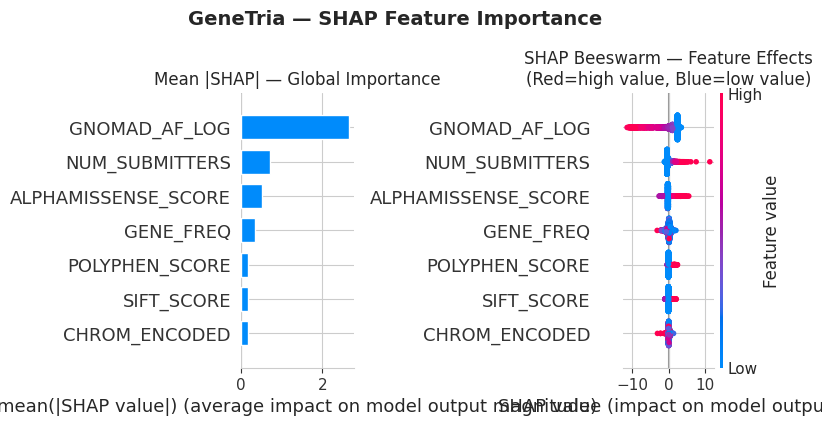

Feature importance ranking:
  GNOMAD_AF_LOG            : 2.6531
  NUM_SUBMITTERS           : 0.7092
  ALPHAMISSENSE_SCORE      : 0.5184
  GENE_FREQ                : 0.3504
  POLYPHEN_SCORE           : 0.1879
  SIFT_SCORE               : 0.1848
  CHROM_ENCODED            : 0.1701

✅ SHAP summary saved


In [ ]:
# ============================================================
# PLOT 1: SHAP SUMMARY — Global Feature Importance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("GeneTriage — SHAP Feature Importance",
             fontsize=14, fontweight='bold')

# Left: Bar plot — mean absolute SHAP value per feature
plt.sca(axes[0])
shap.summary_plot(
    sv_pathogenic,
    X_shap,
    feature_names=FEATURE_COLS,
    plot_type="bar",
    show=False
)
axes[0].set_title("Mean |SHAP| — Global Importance")

# Right: Beeswarm — shows direction and magnitude
plt.sca(axes[1])
shap.summary_plot(
    sv_pathogenic,
    X_shap,
    feature_names=FEATURE_COLS,
    plot_type="dot",
    show=False
)
axes[1].set_title("SHAP Beeswarm — Feature Effects\n"
                  "(Red=high value, Blue=low value)")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/GenePath/genepath_shap_summary.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Print ranked feature importance
mean_abs_shap = np.abs(sv_pathogenic).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature':   FEATURE_COLS,
    'Mean_SHAP': mean_abs_shap
}).sort_values('Mean_SHAP', ascending=False)

print("Feature importance ranking:")
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:25s}: {row['Mean_SHAP']:.4f}")

print("\n✅ SHAP summary saved")

/tmp/ipykernel_3968/3302493876.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_3968/3302493876.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


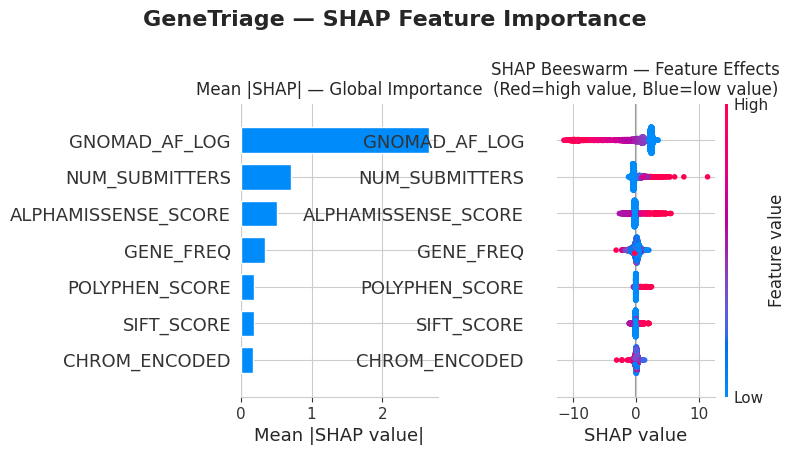

Feature importance ranking:
  GNOMAD_AF_LOG            : 2.6531
  NUM_SUBMITTERS           : 0.7092
  ALPHAMISSENSE_SCORE      : 0.5184
  GENE_FREQ                : 0.3504
  POLYPHEN_SCORE           : 0.1879
  SIFT_SCORE               : 0.1848
  CHROM_ENCODED            : 0.1701

✅ SHAP summary saved


In [ ]:
# ============================================================
# PLOT 1: SHAP SUMMARY — Global Feature Importance
# ============================================================

# 1. Slightly wider figure to accommodate the middle text
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle("GeneTriage — SHAP Feature Importance",
             fontsize=16, fontweight='bold', y=1.05) # Lifted title slightly

# Left: Bar plot
plt.sca(axes[0])
shap.summary_plot(
    sv_pathogenic,
    X_shap,
    feature_names=FEATURE_COLS,
    plot_type="bar",
    show=False
)
axes[0].set_title("Mean |SHAP| — Global Importance")
# 3. Overwrite SHAP's verbose x-axis label
axes[0].set_xlabel("Mean |SHAP value|")

# Right: Beeswarm
plt.sca(axes[1])
shap.summary_plot(
    sv_pathogenic,
    X_shap,
    feature_names=FEATURE_COLS,
    plot_type="dot",
    show=False
)
axes[1].set_title("SHAP Beeswarm — Feature Effects\n"
                  "(Red=high value, Blue=low value)")
# 3. Overwrite SHAP's verbose x-axis label
axes[1].set_xlabel("SHAP value")

# 2. Manually adjust layout instead of using plt.tight_layout()
# wspace controls the width between the subplots. Increase if still colliding.
# bottom ensures the x-axis labels aren't cut off.
plt.subplots_adjust(wspace=0.6, bottom=0.15)

plt.savefig("/content/drive/MyDrive/GenePath/genepath_shap_summary.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Print ranked feature importance
mean_abs_shap = np.abs(sv_pathogenic).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature':   FEATURE_COLS,
    'Mean_SHAP': mean_abs_shap
}).sort_values('Mean_SHAP', ascending=False)

print("Feature importance ranking:")
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:25s}: {row['Mean_SHAP']:.4f}")

print("\n✅ SHAP summary saved")

Explaining variant #1708
Model probability: 0.978

Feature values for this variant:
  CHROM_ENCODED            : 2.0000
  GENE_FREQ                : 8923.0000
  NUM_SUBMITTERS           : 6.0000
  SIFT_SCORE               : 0.9125
  POLYPHEN_SCORE           : 1.0000
  ALPHAMISSENSE_SCORE      : 0.9826
  GNOMAD_AF_LOG            : -5.0904


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


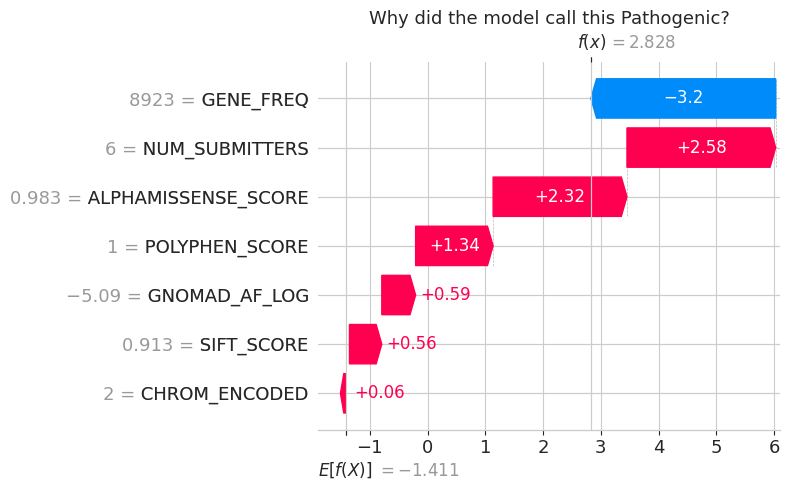

✅ Waterfall plot saved


In [ ]:
# ============================================================
# PLOT 2: WATERFALL — Single Variant Explanation
# Explains exactly why the model flagged one variant
# ============================================================

# Find highest-confidence pathogenic prediction in our sample
pathogenic_mask  = y_shap == 1
pathogenic_probs = stack.predict_proba(X_shap[pathogenic_mask])[:, 1]
best_local_idx   = np.argmax(pathogenic_probs)
actual_idx       = np.where(pathogenic_mask)[0][best_local_idx]

print(f"Explaining variant #{actual_idx}")
print(f"Model probability: {pathogenic_probs[best_local_idx]:.3f}")
print(f"\nFeature values for this variant:")
for feat, val in zip(FEATURE_COLS, X_shap[actual_idx]):
    print(f"  {feat:25s}: {val:.4f}")

# Get expected value (base rate)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values        = sv_pathogenic[actual_idx],
        base_values   = base_val,
        data          = X_shap[actual_idx],
        feature_names = FEATURE_COLS
    ),
    show=False
)
plt.title("Why did the model call this Pathogenic?", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/GenePath/genepath_shap_waterfall.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved")

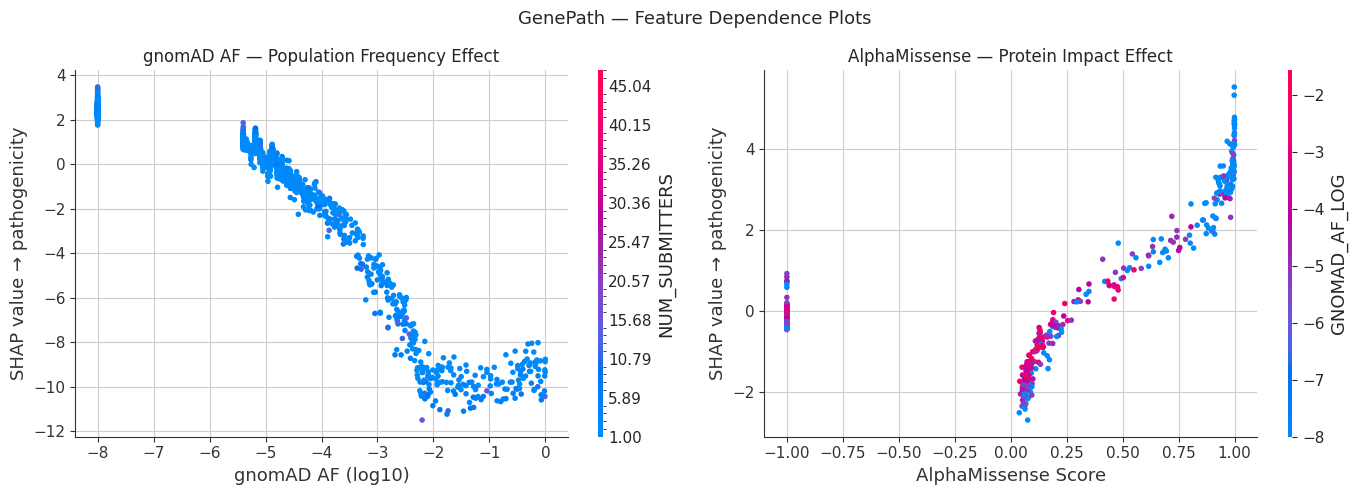

✅ Dependence plots saved

🎉 Stage 6 Complete — All SHAP analysis done

Files saved to Drive:
  genepath_shap_summary.png
  genepath_shap_waterfall.png
  genepath_shap_dependence.png

Next step: FastAPI backend


In [ ]:
# ============================================================
# PLOT 3: DEPENDENCE PLOTS
# How gnomAD AF and AlphaMissense affect predictions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GenePath — Feature Dependence Plots", fontsize=13)

gnomad_idx = FEATURE_COLS.index('GNOMAD_AF_LOG')
alpha_idx  = FEATURE_COLS.index('ALPHAMISSENSE_SCORE')

# Left: gnomAD AF
shap.dependence_plot(
    gnomad_idx,
    sv_pathogenic,
    X_shap,
    feature_names=FEATURE_COLS,
    ax=axes[0],
    show=False
)
axes[0].set_title("gnomAD AF — Population Frequency Effect")
axes[0].set_xlabel("gnomAD AF (log10)")
axes[0].set_ylabel("SHAP value → pathogenicity")

# Right: AlphaMissense
shap.dependence_plot(
    alpha_idx,
    sv_pathogenic,
    X_shap,
    feature_names=FEATURE_COLS,
    ax=axes[1],
    show=False
)
axes[1].set_title("AlphaMissense — Protein Impact Effect")
axes[1].set_xlabel("AlphaMissense Score")
axes[1].set_ylabel("SHAP value → pathogenicity")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/GenePath/genepath_shap_dependence.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Dependence plots saved")
print("\n🎉 Stage 6 Complete — All SHAP analysis done")
print("\nFiles saved to Drive:")
print("  genepath_shap_summary.png")
print("  genepath_shap_waterfall.png")
print("  genepath_shap_dependence.png")
print("\nNext step: FastAPI backend")